# Quickstart: From dataset to predictions and evaluation

This tutorial works with a sample dataset (with only one document) that is present in the repo (no need to download anything). To see how to properly work with larger datasets, check [Load and Sample Dataset](load_and_sample_dataset.md) tutorial.

## Load sample dataset

In [1]:
from pathlib import Path
from docile.dataset import CachingConfig, Dataset

DATASET_PATH = Path("../tests/data/sample-dataset/")
sample_dataset = Dataset("dev", DATASET_PATH)

Loading documents for sample-dataset:dev: 100%|██████████| 1/1 [00:00<00:00, 463.10it/s]


In [2]:
print(f"{sample_dataset} with {len(sample_dataset)} docs and {sample_dataset.total_page_count()} pages")

Dataset(sample-dataset:dev) with 1 docs and 1 pages


In [3]:
sample_doc = sample_dataset[0]
print(sample_doc)

Document(sample-dataset:516f2d61ea404b30a9192a72)


## Browse available document resources

**Read pdf and convert it to image**

In [4]:
pdf_bytes = sample_doc.data_paths.pdf_path(sample_doc.docid).read_bytes()

In [5]:
pdf_bytes[:20]

b'%PDF-1.3\n%\x8f\n1 0 obj\n'

Convert to image with a width set to 500 pixels.

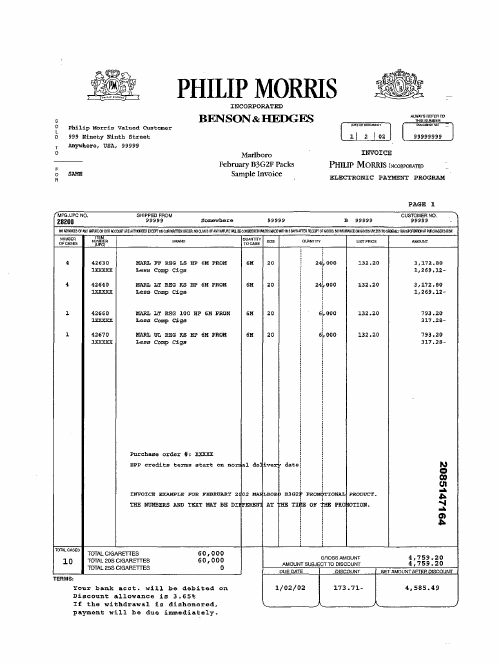

In [6]:
sample_doc.page_image(page=0, image_size=(500, None))

**Access & visualize annotations**

In [7]:
print(f"{sample_doc.annotation.fields[0]=}\n")
print(f"{sample_doc.annotation.li_fields[0]=}\n")
print(f"{sample_doc.annotation.li_headers[0]=}\n")
print(f"{sample_doc.annotation.cluster_id=}")
print(f"{sample_doc.annotation.document_type=}")
print(f"{len(sample_doc.annotation.get_table_grid(page=0).rows_bbox_with_type)=}")
print()
print("Access raw annotations dictionary:")
print(f"{sample_doc.annotation.content.keys()=}")

sample_doc.annotation.fields[0]=Field(bbox=BBox(left=0.8201612903225807, top=0.19939209726443768, right=0.8838709677419355, bottom=0.20972644376899696), page=0, text='99999999', fieldtype='document_id')

sample_doc.annotation.li_fields[0]=Field(bbox=BBox(left=0.12580645161290321, top=0.3884498480243161, right=0.14112903225806453, bottom=0.4006079027355623), page=0, text='4', fieldtype='line_item_quantity', line_item_id=1)

sample_doc.annotation.li_headers[0]=Field(bbox=BBox(left=0.11370967741935484, top=0.35303951367781156, right=0.15564516129032258, bottom=0.3700607902735562), page=0, text='NUMBER\nOF CASES', fieldtype='line_item_quantity', line_item_id=0)

sample_doc.annotation.cluster_id=554
sample_doc.annotation.document_type='tax_invoice'
len(sample_doc.annotation.get_table_grid(page=0).rows_bbox_with_type)=17

Access raw annotations dictionary:
sample_doc.annotation.content.keys()=dict_keys(['field_extractions', 'line_item_extractions', 'line_item_headers', 'metadata'])


Show annotations in the dataset browser

In [8]:
from docile.tools.dataset_browser import DatasetBrowser

browser = DatasetBrowser(sample_dataset)

**Access Pre-computed OCR**

Word tokens of the pre-computed OCR can be easily accessed in two variants, with `snapped=False` and `snapped=True`. The first version is computed by DocTR and the second version uses some heuristics to remove whitespace around the edges of the predictions. The snapped OCR word boxes are also used to generate the Pseudo-Character-Centers which are used in evaluation (check the dataset paper or code for details).

In [9]:
words = sample_doc.ocr.get_all_words(page=0)
snapped_words = sample_doc.ocr.get_all_words(page=0, snapped=True)
print(words[0])
print(snapped_words[0])

Field(bbox=BBox(left=0.353515625, top=0.1171875, right=0.4931640625, bottom=0.1484375), page=0, text='PHILIP')
Field(bbox=BBox(left=0.3540189125295508, top=0.11804008908685969, right=0.4929078014184397, bottom=0.14788418708240533), page=0, text='PHILIP')


Show crop of the document page with pre-computed OCR words. Blue boxes are the original boxes, red boxes are the snapped boxes

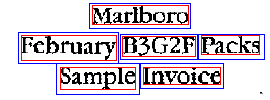

In [10]:
from PIL import ImageDraw

page_img = sample_doc.page_image(0, image_size=(1600, None))

draw_img = page_img.copy()
draw = ImageDraw.Draw(draw_img, "RGB")
for word in sample_doc.ocr.get_all_words(page=0, snapped=False):
    scaled_bbox = word.bbox.to_absolute_coords(*draw_img.size)
    draw.rectangle(scaled_bbox.to_tuple(), outline="blue")
for word in sample_doc.ocr.get_all_words(page=0, snapped=True):
    scaled_bbox = word.bbox.to_absolute_coords(*draw_img.size)
    draw.rectangle(scaled_bbox.to_tuple(), outline="red")
draw_img.crop((680, 480, 950, 580))

Access raw OCR content

In [11]:
ocr_dict = sample_doc.ocr.content
ocr_dict["pages"][0]["blocks"][4]

{'geometry': [[0.4365234375, 0.2275390625], [0.58984375, 0.2705078125]],
 'lines': [{'geometry': [[0.48046875, 0.2275390625],
    [0.5439453125, 0.2392578125]],
   'words': [{'value': 'Marlboro',
     'confidence': 0.9411603212356567,
     'geometry': [[0.48046875, 0.2275390625], [0.5439453125, 0.2392578125]],
     'snapped_geometry': [[0.48226950354609927, 0.2285077951002227],
      [0.5425531914893617, 0.2374164810690423]]}]},
  {'geometry': [[0.4365234375, 0.2412109375], [0.58984375, 0.255859375]],
   'words': [{'value': 'February',
     'confidence': 0.7711520195007324,
     'geometry': [[0.4365234375, 0.2412109375], [0.4990234375, 0.255859375]],
     'snapped_geometry': [[0.4379432624113475, 0.24276169265033407],
      [0.49763593380614657, 0.2543429844097996]]},
    {'value': 'B3G2F',
     'confidence': 0.9990770816802979,
     'geometry': [[0.5, 0.2421875], [0.5478515625, 0.25390625]],
     'snapped_geometry': [[0.5011820330969267, 0.24320712694877505],
      [0.5466903073286052

## Create dummy predictions

Create predictions as perturbations of the gold labels (just as example). Some labels are thrown away and for some labels, two predictions are created instead of one.

In [12]:
from dataclasses import replace
from random import Random
from typing import List, Sequence, Tuple

from docile.dataset import BBox, Document, Field

def fields_perturbation(rng: Random, fields: Sequence[Field], max_shift: Tuple[float, float]) -> List[Field]:
    new_fields = []
    for field in fields:
        p = rng.random()
        generate_fields = 1
        if p < 0.2:
            generate_fields = 0
        elif p > 0.9:
            generate_fields = 2
        for _ in range(generate_fields):
            max_shift_horizontal, max_shift_vertical = max_shift
            left = field.bbox.left + (rng.random() * 2 - 1) * max_shift_horizontal
            right = field.bbox.right + (rng.random() * 2 - 1) * max_shift_horizontal
            if right < left:
                left, right = right, left
            top = field.bbox.top + (rng.random() * 2 - 1) * max_shift_vertical
            bottom = field.bbox.bottom + (rng.random() * 2 - 1) * max_shift_vertical
            if bottom < top:
                top, bottom = bottom, top
            new_field = replace(field, bbox=BBox(left, top, right, bottom))
            new_fields.append(new_field)
    return new_fields
        
def get_max_shift_in_relative_coords(doc: Document, max_shift_px_at_200dpi: Tuple[int, int]) -> Tuple[float, float]:
    size_at_200dpi = doc.page_image_size(page=0, dpi=200)
    return (max_shift_px_at_200dpi[0] / size_at_200dpi[0], max_shift_px_at_200dpi[1] / size_at_200dpi[1])

In [13]:
rng = Random(42)

max_shift = get_max_shift_in_relative_coords(sample_doc, max_shift_px_at_200dpi=(15, 5))
kile_predictions = {sample_doc.docid: fields_perturbation(rng, sample_doc.annotation.fields, max_shift)}
lir_predictions = {sample_doc.docid: fields_perturbation(rng, sample_doc.annotation.li_fields, max_shift)}

**Store predictions to json**

In this format predictions are submitted to the benchmark. With the predictions stored on disk you can also run the evaluation from command line with `docile_evaluate` command.

In [14]:
from docile.dataset import store_predictions

store_predictions(Path("/tmp/kile-perturbations.json"), kile_predictions)

**Run evaluation**

In [15]:
from docile.evaluation import evaluate_dataset

evaluation_result = evaluate_dataset(sample_dataset, kile_predictions, lir_predictions)

Run matching for documents: 100%|██████████| 1/1 [00:00<00:00,  4.79it/s]


In [16]:
print(evaluation_result.print_report())

Evaluation report for sample-dataset:dev
KILE
----
Primary metric (AP): 0.3677685950413223

| fieldtype                 |    AP |    f1 |   precision |   recall |   TP |   FP |   FN |
|---------------------------|-------|-------|-------------|----------|------|------|------|
| **-> micro average**      | 0.368 | 0.545 |       0.545 |    0.545 |    6 |    5 |    5 |
| account_num               | 0.000 | 0.000 |       0.000 |    0.000 |    0 |    0 |    0 |
| amount_due                | 0.000 | 0.000 |       0.000 |    0.000 |    0 |    1 |    1 |
| amount_paid               | 0.000 | 0.000 |       0.000 |    0.000 |    0 |    0 |    0 |
| amount_total_gross        | 1.000 | 1.000 |       1.000 |    1.000 |    1 |    0 |    0 |
| amount_total_net          | 0.000 | 0.000 |       0.000 |    0.000 |    0 |    0 |    0 |
| amount_total_tax          | 0.000 | 0.000 |       0.000 |    0.000 |    0 |    0 |    0 |
| bank_num                  | 0.000 | 0.000 |       0.000 |    0.000 |    0 |   

In [17]:
evaluation_result.get_primary_metric("kile")

0.3677685950413223

**Visualize matching**

In [18]:
kile_matching = evaluation_result.task_to_docid_to_matching["kile"]
lir_matching = evaluation_result.task_to_docid_to_matching["lir"]
DatasetBrowser(sample_dataset, kile_matching=kile_matching, lir_matching=lir_matching)